In [1]:
import transformers
from transformers.models.llama import modeling_llama
from transformers import LlamaConfig
import torch
from torch import nn
LlamaDecoderLayer = modeling_llama.LlamaDecoderLayer # for some reason the import only works like this on my laptop
from tokenizer_layer import TokenizerLayer, TokenizerLayerV2

In [2]:
pad_token_id = 256

config = LlamaConfig(
    vocab_size=257,
    hidden_size=512,
    intermediate_size=1024,
    num_hidden_layers=4,
    num_attention_heads=8,
    max_position_embeddings=512,
    rms_norm_eps=1e-6,
    initializer_range=0.02,
    use_cache=True,
    pad_token_id=pad_token_id,
    # bos_token_id=tokenizer.bos_token_id,
    # eos_token_id=tokenizer.eos_token_id,
    tie_word_embeddings=False,
)

torch.manual_seed(0)
tokenizer_layer = TokenizerLayer(
    config,
    layer_idx=1,
    starting_vocab=[(i,) for i in range(257)],
    backbone_len=2,
    embeder_len=2,
    combination_threshold=0.00001
    )

In [3]:
tokenizer_layer_v2 = TokenizerLayerV2(
    config,
    layer_idx=1,
    starting_vocab=[(i,) for i in range(257)],
    common_backbone_len=2,
    embeder_len=2,
    passing_threshold=0.5 # mean of values being compared at init is 0.5 
    )

In [5]:
import torch
from datasets import load_dataset
utf_8_dataset = load_dataset(
    "json",
    data_files={"train": "train.json", "test": "test.json"},
    split="train"
    )
utf_8_dataset

def pad_sft_collator(batch, padding_value: int=257, padding_side = "left"):
    # TODO: implement this function
    tensor_batch_ids = [torch.tensor(x['input_ids']) for x in batch]
    tensor_batch_labels = [torch.tensor(x['labels']) for x in batch]

    input_ids = torch.nn.utils.rnn.pad_sequence(
        tensor_batch_ids,
        padding_value=padding_value,
        padding_side=padding_side,
        ).T
    labels = torch.nn.utils.rnn.pad_sequence(
        tensor_batch_labels,
        padding_value=padding_value,
        padding_side=padding_side,
        ).T

    attention_mask = []
    max_len = input_ids.shape[-1]
    for ids in tensor_batch_ids:
        ids_len = len(ids)
        if padding_side == "left":
            new_mask = torch.tensor([0]*(max_len-ids_len) + [1]*ids_len)
        else:
            new_mask = torch.tensor([1]*ids_len + [0]*(max_len-ids_len))
        attention_mask.append(new_mask)

    attention_mask = torch.stack(attention_mask)#torch.ones_like(input_ids)

    # of shape (batch size, sequence length), input_ids/labels is of dtype long, the mask bool
    return {
        'input_ids': input_ids,
        'labels': labels,
        'attention_mask': attention_mask,
    }

# test that the function runs fine
batch_size = 2
batch = utf_8_dataset.select(range(batch_size))

padded_batch = pad_sft_collator(batch, padding_value=256) # padding value should be beyond the range of numbers representable by one byte
padded_batch["input_ids"].shape

torch.Size([2, 198])

In [6]:
padded_batch["attention_mask"]

tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
         1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,


In [7]:
# minimal working network for testing
layer_version = tokenizer_layer_v2
embeder = nn.Embedding(257, 512)
input_ids = padded_batch["input_ids"]
attention_mask = padded_batch["attention_mask"]
batched_tokens = []
for x in input_ids.tolist():
    tupled_ids = list(map(lambda y: (y,), x))
    batched_tokens.append(tupled_ids)
base_embeddings = embeder(input_ids)
hidden_states, batched_tokens, attention_mask = layer_version(base_embeddings, batched_tokens, attention_mask)
base_embeddings.shape, hidden_states.shape, attention_mask.shape

(torch.Size([2, 198, 512]), torch.Size([2, 125, 512]), torch.Size([2, 198]))

In [8]:
#tokenizer_layer_v2.embedding_weights.shape

In [9]:
batched_tokens[1][:7]

[(240,), (162,), (147,), (163,), (240, 178), (131, 142, 37), (36, 232)]

In [10]:
out = hidden_states
rand_target = torch.randint(0, out.shape[-1], out.shape[:-1])
loss_fn = torch.nn.NLLLoss()
loss = loss_fn(out.transpose(-1, -2), rand_target)
loss.backward()

No gradient for: pad_embed.weight


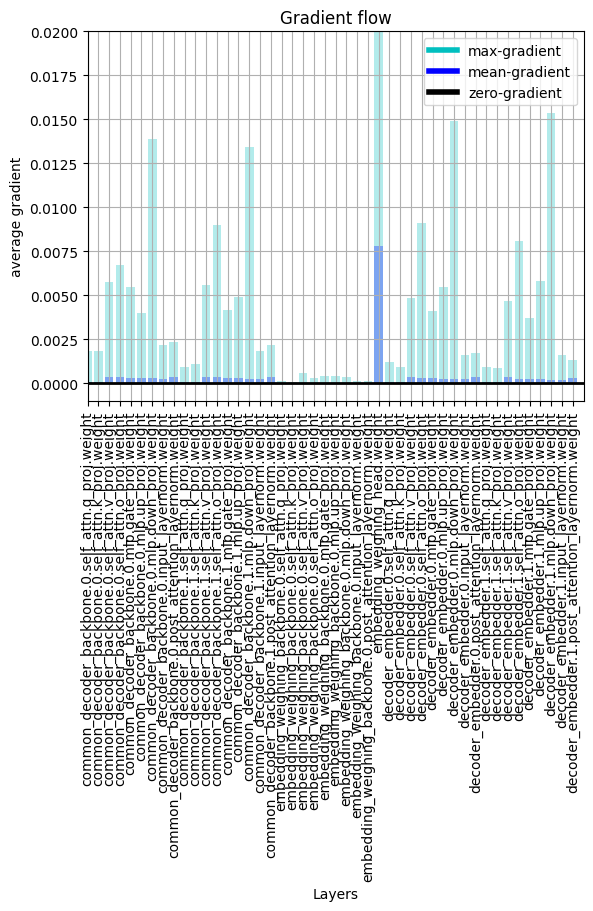

In [22]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
def plot_grad_flow(named_parameters):
    # https://gist.github.com/Flova/8bed128b41a74142a661883af9e51490
    '''Plots the gradients flowing through different layers in the net during training.
    Can be used for checking for possible gradient vanishing / exploding problems.
    
    Usage: Plug this function in Trainer class after loss.backwards() as 
    "plot_grad_flow(self.model.named_parameters())" to visualize the gradient flow'''
    ave_grads = []
    max_grads= []
    layers = []
    for n, p in named_parameters:
        if (p.requires_grad) and ("bias" not in n)\
            and not (p.grad is None):
            layers.append(n)
            ave_grads.append(p.grad.abs().mean().item())
            max_grads.append(p.grad.abs().max().item())
        if (p.grad is None):
            print("No gradient for:", n)
    plt.bar(np.arange(len(max_grads)), max_grads, alpha=0.3, lw=1, color="c")
    plt.bar(np.arange(len(max_grads)), ave_grads, alpha=0.3, lw=1, color="b")
    plt.hlines(0, 0, len(ave_grads)+1, lw=2, color="k" )
    plt.xticks(range(0,len(ave_grads), 1), layers, rotation="vertical")
    plt.xlim(left=0, right=len(ave_grads))
    plt.ylim(bottom = -0.001, top=0.02) # zoom in on the lower gradient regions
    plt.xlabel("Layers")
    plt.ylabel("average gradient")
    plt.title("Gradient flow")
    plt.grid(True)
    plt.legend([Line2D([0], [0], color="c", lw=4),
                Line2D([0], [0], color="b", lw=4),
                Line2D([0], [0], color="k", lw=4)], ['max-gradient', 'mean-gradient', 'zero-gradient'])
    
plot_grad_flow(layer_version.named_parameters())

In [12]:
tokenizer_layer.tokenizer_head = nn.Linear(in_features=512, out_features=258, bias=True)
tokenizer_layer.tokenizer_head 

Linear(in_features=512, out_features=258, bias=True)

In [13]:
# expanding tokenizer head for larger size if vocab increases
old_head_weight = tokenizer_layer.tokenizer_head.weight
old_head_vocab_size = old_head_weight.shape[0]

new_head = nn.Linear(in_features=512, out_features=300, bias=True)
with torch.no_grad():
    new_head.weight[:old_head_vocab_size] = old_head_weight

In [14]:
old_head_weight.shape, new_head.weight.shape

(torch.Size([258, 512]), torch.Size([300, 512]))

In [15]:
from vocab_manager import DynamicHead, DynamicVocabHead
dynamic_head = DynamicHead(512, 100)

In [16]:
dynamic_head.expand_head(150)
dynamic_head

DynamicHead(
  (head): Linear(in_features=512, out_features=150, bias=True)
)

In [17]:
dynamic_vocab_head = DynamicVocabHead(512, [(i,) for i in range(50)])

In [18]:
dvh = dynamic_vocab_head
#dvh.vocab_manger


In [19]:
dynamic_head(hidden_states)[0,0,:5]

tensor([-0.1973,  0.0296,  1.2064, -0.3687, -0.7765], grad_fn=<SliceBackward0>)